# Wave Roses from Mathieu - read them

In [225]:
import pandas as pd 

In [226]:
df = pd.read_csv('/Users/bmapes/Box/GWaves_MERGIR_Mathieu/2023_Sep-Nov/Statistics/WaveStats_5deg.csv')
df

,BatchStartDate,BatchEndDate,ROI_ID,CenterLat,CenterLon,Speed_S1_A1,Speed_S1_A2,Speed_S1_A3,Speed_S1_A4,Speed_S1_A5,...,Speed_S6_A6,Speed_S6_A7,Speed_S6_A8,Speed_S6_A9,Speed_S6_A10,Speed_S6_A11,Speed_S6_A12,Speed_S6_A13,Speed_S6_A14,Speed_S6_A15
0,2023-09-01 00:00:00,2023-09-01 05:30:00,1,5.0758,-122.6132,1.6732,1.8523,2.2524,2.1585,2.0798,...,0.2190,-0.7250,-0.2166,0.3388,-1.0324,1.4023,3.5905,1.8139,2.2158,0.8143
1,2023-09-01 00:00:00,2023-09-01 05:30:00,2,5.0758,-117.5930,0.3341,0.4345,0.5068,0.4930,0.6439,...,0.9133,-1.3086,-0.9052,0.5055,-0.3900,1.7102,1.6022,1.6056,1.5976,1.5011
2,2023-09-01 00:00:00,2023-09-01 05:30:00,3,5.0758,-112.5728,0.4649,0.5788,0.6101,0.5771,0.5946,...,-4.7795,-4.9409,-2.8657,-0.4459,0.6813,-1.2865,0.3877,0.4112,0.8310,2.8806
3,2023-09-01 00:00:00,2023-09-01 05:30:00,4,5.0758,-107.5525,0.3234,0.3775,0.3619,0.3843,0.3374,...,0.5271,-2.3248,-0.5663,-0.1573,-0.7201,-0.6244,0.8112,0.9039,0.3832,3.1827
4,2023-09-01 00:00:00,2023-09-01 05:30:00,5,5.0758,-102.5323,1.6764,1.9608,2.1621,2.0360,1.7794,...,1.2450,-0.4976,-0.3200,-0.1259,0.4845,1.3889,1.9735,2.4184,1.5666,2.6573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29115,2023-11-30 18:00:00,2023-11-30 23:30:00,76,-30.0728,-97.5121,-0.1027,-0.2062,-0.2046,-0.0655,-0.1655,...,-0.8253,-0.2995,-0.5032,0.9174,-0.3827,-0.1067,0.9503,2.0801,0.7756,0.9712
29116,2023-11-30 18:00:00,2023-11-30 23:30:00,77,-30.0728,-92.4919,-0.2178,-0.3397,-0.1510,-0.0915,-0.0891,...,0.7201,-1.7884,-0.8056,-0.6906,-1.3710,0.2178,-0.0912,-1.7850,-1.7551,-1.3359
29117,2023-11-30 18:00:00,2023-11-30 23:30:00,78,-30.0728,-87.4717,-0.2101,-0.4379,-0.3418,-0.2386,-0.2306,...,-0.9585,0.4527,-0.1238,-0.6084,0.4763,-1.8238,-3.2411,-0.9998,-2.1182,-2.1860
29118,2023-11-30 18:00:00,2023-11-30 23:30:00,79,-30.0728,-82.4515,-0.3979,-0.5414,-0.5321,-0.3361,-0.2954,...,-0.9068,-1.0991,-0.2646,0.5494,0.6930,-0.3559,-2.7942,-0.3339,0.5784,-1.7555


In [227]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Build speed array and Dataset
speed_cols = [f"Speed_S{s}_A{a}" for s in range(1, 7) for a in range(1, 16)]
speed_values = df[speed_cols].values.reshape(-1, 6, 15)  # (rows, scales, angles)

# Define coordinates explicitly as arrays/lists
scale_coords = np.arange(2, 8)  # or list(range(2, 8))
angle_coords = np.arange(0, 15) * 360.0 / 28.0

ds = xr.Dataset(
    {"speed": (["row", "scale", "angle"], speed_values)},
    coords={
        "scale":          scale_coords,
        "angle":          angle_coords,
        "BatchStartDate": ("row", pd.to_datetime(df["BatchStartDate"].values)),
        "CenterLat":      ("row", df["CenterLat"].values.astype(float)),
        "CenterLon":      ("row", df["CenterLon"].values.astype(float)),
    }
)


# Promote lat, lon, time to proper dimensions
combined = (ds
    .swap_dims({"row": "BatchStartDate"})
    .set_index(row=["BatchStartDate", "CenterLat", "CenterLon"])
    .unstack("row")
)

ds = combined 
ds

<xarray.Dataset> Size: 21MB
Dimensions:         (BatchStartDate: 364, CenterLat: 8, CenterLon: 10,
                     scale: 6, angle: 15)
Coordinates:
  * BatchStartDate  (BatchStartDate) datetime64[ns] 3kB 2023-09-01 ... 2023-1...
  * CenterLat       (CenterLat) float64 64B -30.07 -25.05 ... 0.0546 5.076
  * CenterLon       (CenterLon) float64 80B -122.6 -117.6 ... -82.45 -77.43
  * scale           (scale) int64 48B 2 3 4 5 6 7
  * angle           (angle) float64 120B 0.0 12.86 25.71 ... 154.3 167.1 180.0
Data variables:
    speed           (scale, angle, BatchStartDate, CenterLat, CenterLon) float64 21MB ...

In [228]:
def plot_rose(ax, speed_2d, vmin=None, vmax=None, cmap=plt.cm.RdBu_r, **kwargs):
    scales = speed_2d.scale.values.astype(float)
    angles = np.deg2rad(speed_2d.angle.values)
    width  = angles[1] - angles[0]
    norm   = plt.Normalize(vmin, vmax)
    dr     = scales[1] - scales[0]          # assume uniform spacing
    edges  = np.append(scales, scales[-1] + dr)   # add outer edge for last scale

    for i in range(len(scales)):
        for j, theta in enumerate(angles):
            val   = float(speed_2d.isel(scale=i, angle=j))
            color = cmap(norm(val))
            ax.bar(theta, edges[i+1] - edges[i], width=width,
                   bottom=edges[i], color=color, edgecolor=color, **kwargs)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor("none")
    ax.set_rlim(1, edges[-1]) # white circle in the middle 

array(15.7897)

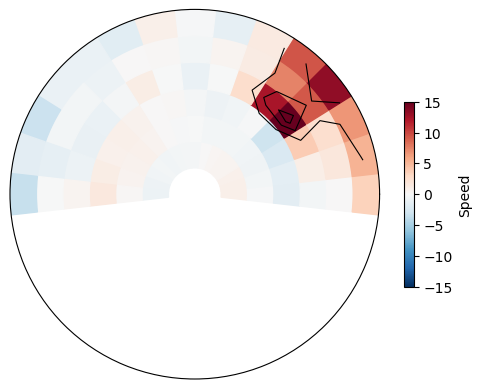

In [229]:
# test plot_rose

vmin = -15; vmax = 15
speed_2d = ds["speed"].isel(CenterLat=2, CenterLon=6).sel(BatchStartDate='2023-10-12T12')

fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
plot_rose(ax, speed_2d, vmin=vmin, vmax=vmax)

# overplot contours 
scales = speed_2d.scale.values.astype(float) + 0.5
angles = np.deg2rad((speed_2d.angle.values))
ax.contour(angles, scales, speed_2d.values, colors="black", levels=[-10,-5,5,10,14], linewidths=0.8);

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(vmin, vmax))
fig.colorbar(sm, ax=fig.axes, shrink=0.5, label="Speed")

speed_2d.max().values

In [230]:
ds["speed"].isel(BatchStartDate=0)

<xarray.DataArray 'speed' (scale: 6, angle: 15, CenterLat: 8, CenterLon: 10)> Size: 58kB
array([[[[-1.30000e-02, -6.12000e-02, -1.62760e+00, ..., -1.66600e-01,
          -9.00000e-02, -1.78800e-01],
         [-2.66100e-01, -1.93150e+00, -5.48000e-01, ...,  3.88900e-01,
           1.44370e+00,  6.62050e+00],
         [ 9.11950e+00, -2.86700e-01, -4.56500e-01, ...,  1.91300e-01,
          -3.52200e-01, -3.53050e+00],
         ...,
         [ 9.08000e-02,  2.43500e-01,  4.34700e-01, ...,  3.10000e-01,
          -1.17054e+01,  1.27700e-01],
         [-4.40800e-01,  2.35400e-01,  8.09200e-01, ..., -8.45710e+00,
          -4.12200e+00,  7.07400e-01],
         [ 1.67320e+00,  3.34100e-01,  4.64900e-01, ...,  3.29400e-01,
           1.11500e-01,  3.35100e-01]],

        [[ 9.10000e-02,  8.95000e-02, -1.37260e+00, ..., -1.77200e-01,
          -5.42000e-02, -1.64700e-01],
         [-2.07800e-01, -1.98360e+00, -9.14200e-01, ...,  5.58300e-01,
          -1.27600e-01,  7.26000e+00],
         [ 7.44760e+00, -1.23100e-01, -9.40800e-01, ..., -1.20000e-01,
          -4.38700e-01, -1.54560e+00],
...
         [-5.97100e-01,  4.93800e-01,  1.38240e+00, ..., -3.01300e-01,
           6.80400e-01, -1.35800e+00],
         [ 5.27400e-01, -7.05100e-01, -6.64300e-01, ...,  6.73500e-01,
          -2.27700e-01,  1.26000e-02],
         [ 2.21580e+00,  1.59760e+00,  8.31000e-01, ...,  2.38600e-01,
           1.14220e+00, -1.11860e+00]],

        [[-5.76900e+00, -8.39560e+00, -7.18540e+00, ..., -1.61900e-01,
          -1.44030e+00, -3.37670e+00],
         [-1.62823e+01, -8.21750e+00, -6.75300e-01, ..., -2.52640e+00,
          -2.66900e+00, -3.65410e+00],
         [-1.19970e+00,  4.72300e-01,  1.26230e+00, ..., -2.73270e+00,
          -3.26400e+00, -1.82060e+00],
         ...,
         [-7.39400e-01, -5.38400e-01, -8.90000e-01, ..., -7.59300e-01,
           4.37500e-01,  1.53000e-02],
         [-2.96800e-01, -3.45700e-01,  1.43530e+00, ...,  5.35100e-01,
          -9.12300e-01,  1.10430e+00],
         [ 8.14300e-01,  1.50110e+00,  2.88060e+00, ...,  1.22200e+00,
           7.76500e-01, -1.79100e-01]]]], shape=(6, 15, 8, 10))
Coordinates:
    BatchStartDate  datetime64[ns] 8B 2023-09-01
  * CenterLat       (CenterLat) float64 64B -30.07 -25.05 ... 0.0546 5.076
  * CenterLon       (CenterLon) float64 80B -122.6 -117.6 ... -82.45 -77.43
  * scale           (scale) int64 48B 2 3 4 5 6 7
  * angle           (angle) float64 120B 0.0 12.86 25.71 ... 154.3 167.1 180.0

In [231]:
def map_of_roses(ds, time, vmin=-10, vmax=10):
    vmin = vmin or float(ds["speed"].min())
    vmax = vmax or float(ds["speed"].max())
    data = ds["speed"].sel(BatchStartDate=time, method="nearest")
    lats = np.sort(ds.CenterLat.values)
    lons = np.sort(ds.CenterLon.values)
    nlat, nlon = len(lats), len(lons)

    fig = plt.figure(figsize=(14, 10))
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            try:
                speed_2d = data.sel(CenterLat=lat, CenterLon=lon)
            except KeyError:
                continue
            x  = j / nlon * 0.85 + 0.05
            y  = i / nlat * 0.85 + 0.05
            ax = fig.add_axes([x, y, 0.85/nlon, 0.85/nlat], projection="polar")
            plot_rose(ax, speed_2d, vmin=vmin, vmax=vmax, cmap=plt.cm.RdBu_r)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdBu_r, norm=plt.Normalize(vmin, vmax))
    fig.colorbar(sm, ax=fig.axes, shrink=0.5, label="Speed")
    fig.text(0.5, 0.01, "Longitude →", ha="center")
    fig.text(0.01, 0.5,  "Latitude →",  va="center", rotation="vertical")
    plt.suptitle(f"Wave roses — {str(time)[:10]}")
    return fig



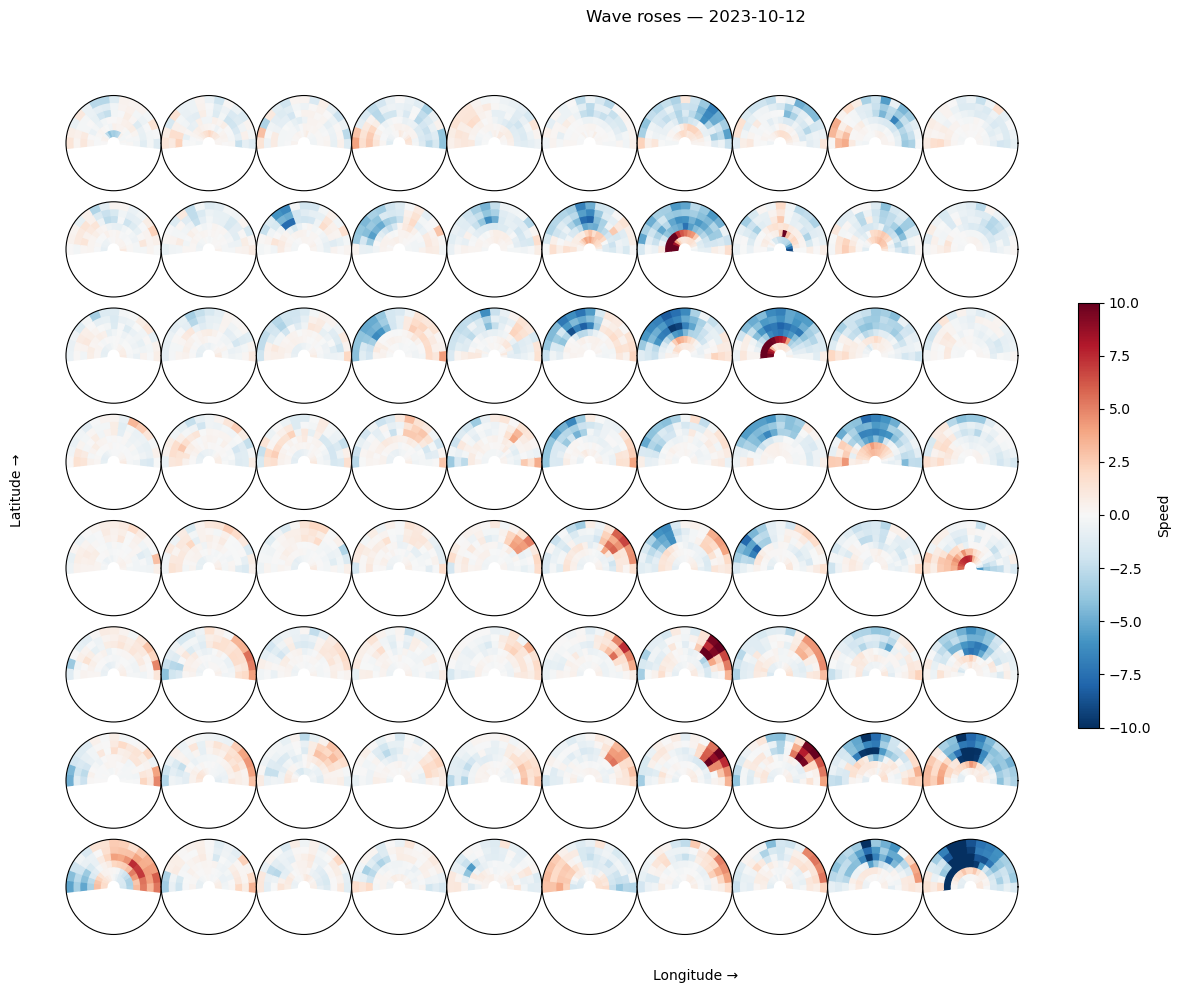

In [232]:
# Make a map of roses for the magic time 2023-10-12T12

data = combined["speed"].sel(BatchStartDate='2023-10-12T12', method="nearest")
fig = map_of_roses(ds, time='2023-10-12T12')

In [233]:
def map_of_roses_instant(ds, vmin=-10, vmax=10, cmap=plt.cm.Blues, titlestr=''):
    vmin = vmin or float(ds["speed"].min())
    vmax = vmax or float(ds["speed"].max())
    data = ds["speed"]
    lats = np.sort(ds.CenterLat.values)
    lons = np.sort(ds.CenterLon.values)
    nlat, nlon = len(lats), len(lons)

    fig = plt.figure(figsize=(14, 10))
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            try:
                speed_2d = data.sel(CenterLat=lat, CenterLon=lon)
            except KeyError:
                continue
            x  = j / nlon * 0.85 + 0.05
            y  = i / nlat * 0.85 + 0.05
            ax = fig.add_axes([x, y, 0.85/nlon, 0.85/nlat], projection="polar")
            plot_rose(ax, speed_2d, vmin=vmin, vmax=vmax, cmap=cmap)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax))
    fig.colorbar(sm, ax=fig.axes, shrink=0.5, label="Speed")
    fig.text(0.5, 0.01, "Longitude →", ha="center")
    fig.text(0.01, 0.5,  "Latitude →",  va="center", rotation="vertical")
    plt.suptitle("frequency of occurrence roses " + titlestr)
    return fig



In [234]:
def map_of_roses_instant_frame(ds, vmin=-10, vmax=10, cmap=plt.cm.Blues, titlestr=''):
    vmin = vmin or float(ds["speed"].min())
    vmax = vmax or float(ds["speed"].max())
    data = ds["speed"]
    lats = np.sort(ds.CenterLat.values)
    lons = np.sort(ds.CenterLon.values)
    nlat, nlon = len(lats), len(lons)

    fig = plt.figure(figsize=(14, 10))

    
    # Set up a frame around all the roseplots for lat,lon axes 
    cell_w = 0.85 / nlon
    cell_h = 0.85 / nlat

    # Reserve explicit axes: roses+frame on left, colorbar on right
    cbar_left = 0.92
    ax_frame = fig.add_axes([0.05, 0.05, cbar_left - 0.07, 0.85])
    ax_frame.set_xlim(lons[0]  - (lons[-1] - lons[0]) / (2*(nlon-1)),
                      lons[-1] + (lons[-1] - lons[0]) / (2*(nlon-1)))
    ax_frame.set_ylim(lats[0]  - (lats[-1] - lats[0]) / (2*(nlat-1)),
                      lats[-1] + (lats[-1] - lats[0]) / (2*(nlat-1)))
    ax_frame.set_xticks(lons); ax_frame.set_xticklabels([f"{v:.1f}°E" for v in lons], fontsize=7)
    ax_frame.set_yticks(lats); ax_frame.set_yticklabels([f"{v:.1f}°N" for v in lats], fontsize=7)
    ax_frame.set_xlabel("Longitude"); ax_frame.set_ylabel("Latitude")
    ax_frame.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
    ax_frame.set_facecolor("none")

    ax_cbar = fig.add_axes([cbar_left, 0.2, 0.02, 0.6])   # explicit colorbar axis
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax))
    fig.colorbar(sm, cax=ax_cbar, label="Speed")



    
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            try:
                speed_2d = data.sel(CenterLat=lat, CenterLon=lon)
            except KeyError:
                continue
            x  = j / nlon * 0.85 + 0.05
            y  = i / nlat * 0.85 + 0.05
            ax = fig.add_axes([x, y, 0.85/nlon, 0.85/nlat], projection="polar")
            plot_rose(ax, speed_2d, vmin=vmin, vmax=vmax, cmap=cmap)

    plt.suptitle("frequency of occurrence roses " + titlestr)
    return fig

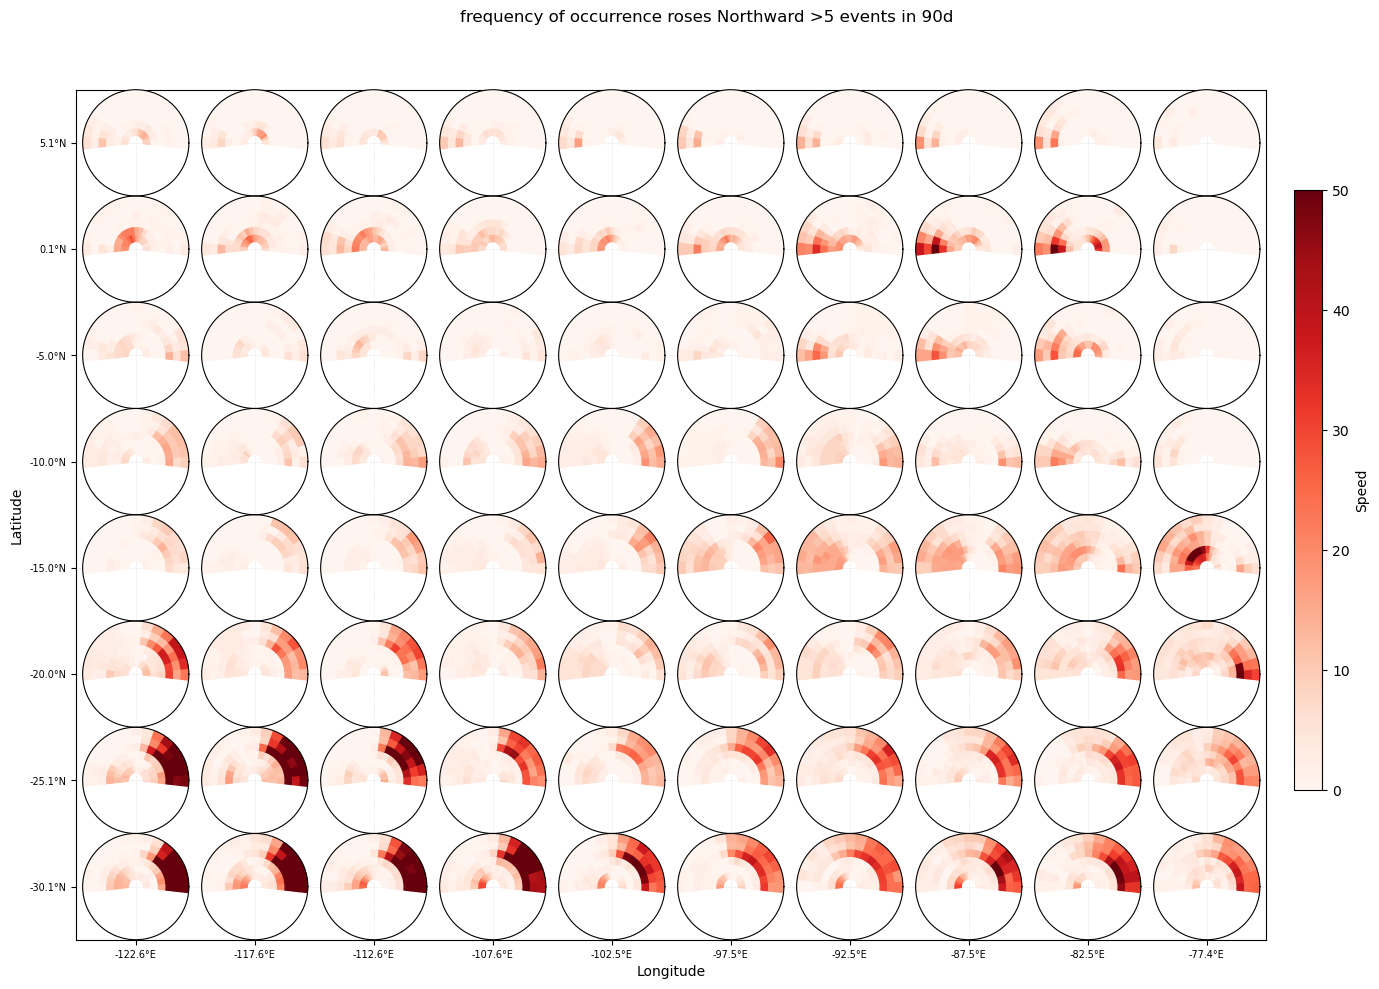

In [235]:
# Statistical plots: how many abs.values exceed 5? (+ or -)
na5events = (np.abs(combined.speed) >5).sum(dim='BatchStartDate')
n_5events = (      combined.speed <-5).sum(dim='BatchStartDate')
n5events  = (      combined.speed > 5).sum(dim='BatchStartDate')

fig = map_of_roses_instant_frame(n5events.to_dataset(), vmin=0, vmax=50, cmap=plt.cm.Reds, 
                                 titlestr='Northward >5 events in 90d')

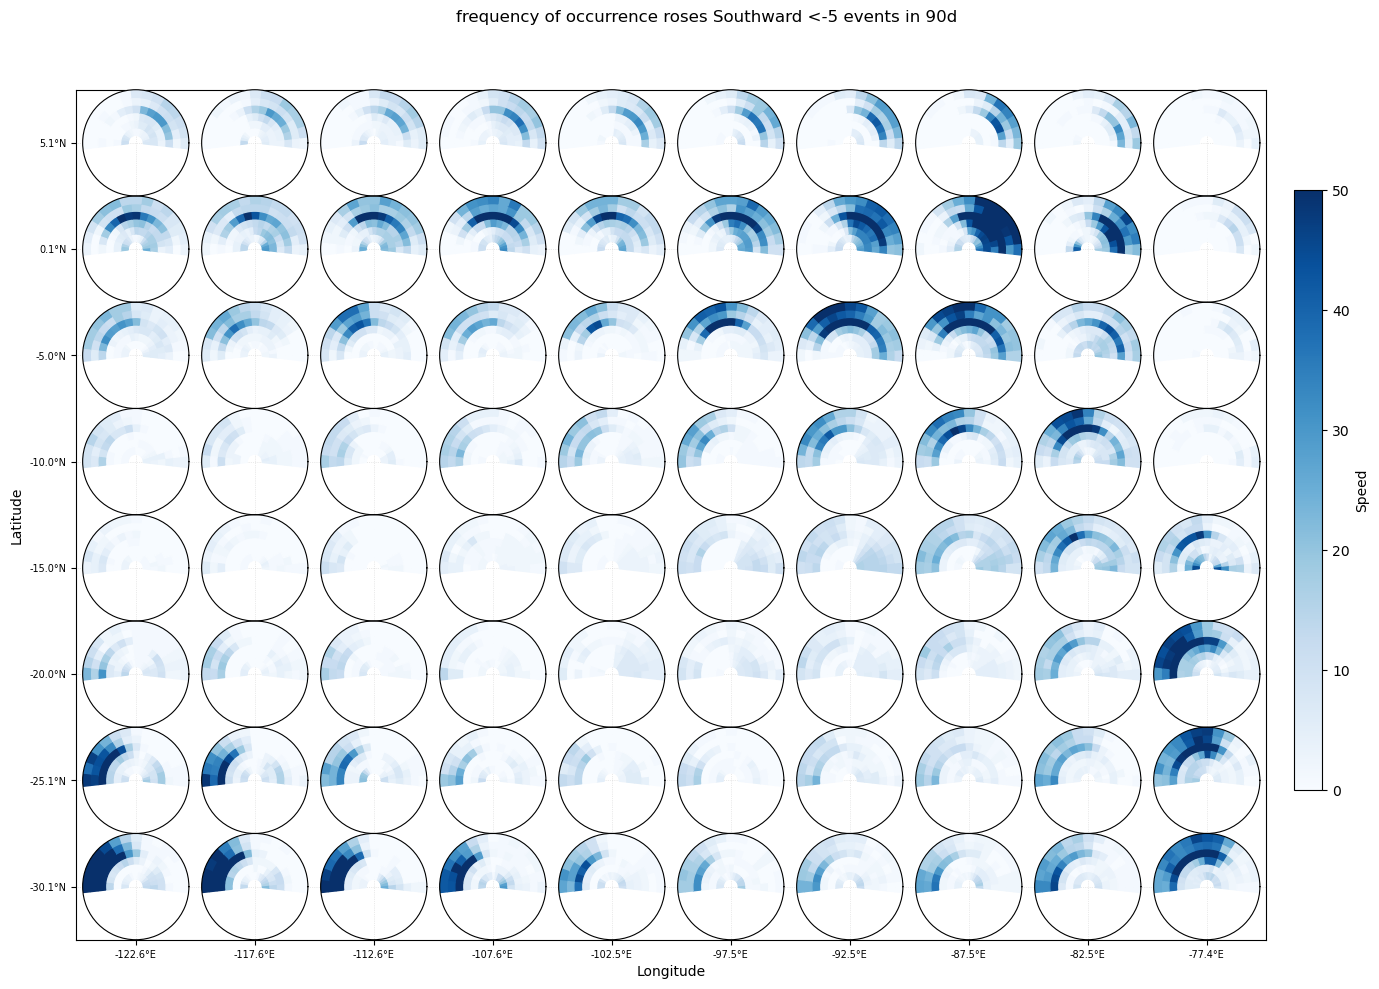

In [236]:
fig = map_of_roses_instant_frame(n_5events.to_dataset(), vmin=0, vmax=50, cmap=plt.cm.Blues, 
                                 titlestr='Southward <-5 events in 90d')